In [9]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [13]:
df = pd.read_csv('../data/Country-data.csv')
scaler = joblib.load('../models/scaler.pkl')
kmeans = joblib.load('../models/kmeans_model.pkl')

features = ['child_mort', 'exports', 'health', 'imports', 'income',
            'inflation', 'life_expec', 'total_fer', 'gdpp']

X_scaled = scaler.transform(df[features])
df['Cluster'] = kmeans.predict(X_scaled)

X = df[features]
y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, 
                                                    random_state=42, stratify=y)

In [14]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2



=== Random Forest ===
Test Accuracy: 1.0000
CV Accuracy: 0.9638
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        21

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



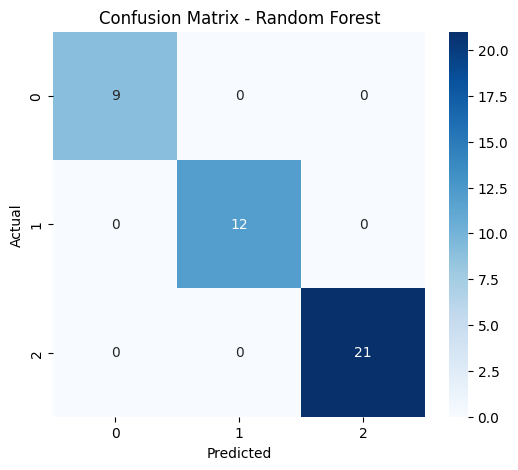


=== XGBoost ===
Test Accuracy: 0.9762
CV Accuracy: 0.9579
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.92      0.96        12
           2       0.95      1.00      0.98        21

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.98        42
weighted avg       0.98      0.98      0.98        42



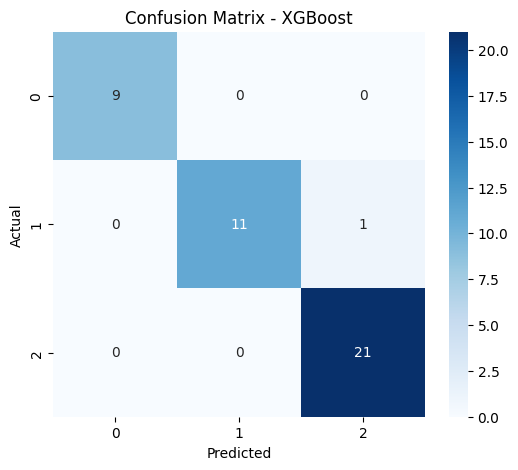

In [15]:

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    cv_score = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    
    results.append([name, acc, cv_score])
    
    print(f"\n=== {name} ===")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"CV Accuracy: {cv_score:.4f}")
    print(classification_report(y_test, pred))
    
    # Confusion Matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, cmap='Blues', fmt='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


In [16]:

estimators = [
    ('rf', RandomForestClassifier(n_estimators=300, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=300, random_state=42))
]

stack = StackingClassifier(estimators=estimators, final_estimator=XGBClassifier(random_state=42))
stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)

print("\n=== Stacking Classifier ===")
print("Accuracy:", accuracy_score(y_test, stack_pred))
print(classification_report(y_test, stack_pred))


=== Stacking Classifier ===
Accuracy: 0.9523809523809523
              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       0.92      1.00      0.96        12
           2       1.00      0.90      0.95        21

    accuracy                           0.95        42
   macro avg       0.94      0.97      0.95        42
weighted avg       0.96      0.95      0.95        42



In [17]:
# Save best model
joblib.dump(stack, '../models/final_model.pkl')
print("\nFinal Stacking model saved as 'final_model.pkl'")


Final Stacking model saved as 'final_model.pkl'
